## Name: Bhumi Koli
## Roll No.34 Batch:2 Class: SE/AIML
## Exp-6: Classification of Credit Card Default Risk using Support Vector Machine

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

In [9]:
data = pd.read_csv('credit.csv', skiprows=1)
data = data.sample(5000, random_state=42)
print(data.columns)

data.drop(columns=['ID'], inplace=True)
print(data.columns)

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [10]:
data.info()
print(data.describe())
print(data.shape)
print(data.tail())
print(data.head())
print(data.dtypes)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64
 14  BILL_

In [11]:
data.isnull().sum()

LIMIT_BAL                     0
GENDER                        0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [12]:
# Target column: default payment (0=No, 1=Yes)
y = data['default payment next month']

# Select only two features for visualisation
X = data[['BILL_AMT1', 'BILL_AMT2']]

print(data.dtypes)
print(data.head())

LIMIT_BAL                     int64
GENDER                        int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object
       LIMIT_BAL  GENDER  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
2308       30000       1          2         2  

In [ ]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)
# Features scaling (imp for SVM- distance + dot product)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SVM with kernel: linear, polynomial, gaussian
from sklearn.svm import SVC
models = {
    "Linear SVM": SVC(kernel='linear', C=1, class_weight='balanced'),
   
    "Polynomial SVM": SVC(kernel='poly',
                          degree=2,
                          C=1,
                          gamma='scale',
                          class_weight='balanced'),
   
    "RBF SVM": SVC(kernel='rbf',
                   C=5,
                   gamma=0.1,
                   class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n", name)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred, zero_division=0))
    print("Recall: ", recall_score(y_test, y_pred))
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("F1 Score: ", f1_score(y_test, y_pred))


 Linear SVM
Confusion Matrix:
 [[ 103 1056]
 [  34  307]]
Precision:  0.2252384446074835
Recall:  0.9002932551319648
Accuracy:  0.2733333333333333
F1 Score:  0.36032863849765256

 Polynomial SVM
Confusion Matrix:
 [[  35 1124]
 [   8  333]]
Precision:  0.22855181880576528
Recall:  0.9765395894428153
Accuracy:  0.24533333333333332
F1 Score:  0.3704115684093437

 RBF SVM
Confusion Matrix:
 [[560 599]
 [166 175]]
Precision:  0.22609819121447028
Recall:  0.5131964809384164
Accuracy:  0.49
F1 Score:  0.3139013452914798


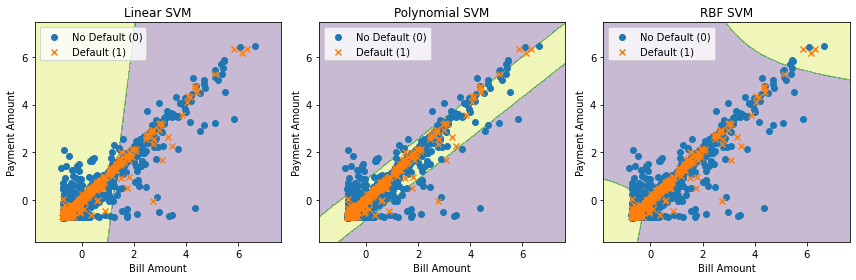

In [ ]:
# Decision Boundary Plotting Function
def plot_boundary(model, title):
    h = 0.02
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
   
    plt.contourf(xx, yy, Z, alpha=0.3)
    # Class 0
    plt.scatter(X_train[y_train == 0, 0],
                X_train[y_train == 0, 1],
                label='No Default (0)',
                marker='o')
    # Class 1
    plt.scatter(X_train[y_train == 1, 0],
                X_train[y_train == 1, 1],
                label='Default (1)',
                marker='x')
    plt.legend()
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("Payment Amount")
# Model Training and Execution 
plt.figure(figsize=(12, 4))
for i, (name, model) in enumerate(models.items()):
    plt.subplot(1, 3, i+1)
    model.fit(X_train, y_train)
    plot_boundary(model, name)
plt.tight_layout()
plt.show()